In [1]:
# =========================================================
# ЕТАП 1: ІНІЦІАЛІЗАЦІЯ ТА ЗАВАНТАЖЕННЯ ДАНИХ
# =========================================================

# 1. Імпорт необхідних бібліотек
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt 
import seaborn as sns # Для візуалізації Матриці Плутанини


# 2. КОНСТАНТИ
FILE_NAME = 'train.csv' 
Y_TARGET = 'Survived'       # Ціль: 0 (загинув) або 1 (вижив)
# Ознаки для КЛАСИФІКАЦІЇ (числові та категоріальні)
# Додамо 'Sex' та 'Embarked' як важливі фактори
X_FEATURES = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex', 'Embarked'] 
RANDOM_SEED = 42

print("Конфігурація:")
print(f"Обрані ознаки (X): {X_FEATURES}")
print(f"Цільова змінна (Y): {Y_TARGET}")


# 3. Завантаження даних
try:
    df_titanic = pd.read_csv(FILE_NAME)
    print(f"\n✅ Дані успішно завантажено. Об'єктів: {df_titanic.shape[0]}, Колонок: {df_titanic.shape[1]}")
except FileNotFoundError:
    print(f"\n❌ Помилка: Файл '{FILE_NAME}' не знайдено.")
    exit()

# 4. Огляд структури
print("\nПерші 5 рядків:")
print(df_titanic.head())
print("\nІнформація про типи даних та пропуски:")
df_titanic.info()

Конфігурація:
Обрані ознаки (X): ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex', 'Embarked']
Цільова змінна (Y): Survived

✅ Дані успішно завантажено. Об'єктів: 891, Колонок: 12

Перші 5 рядків:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0        

In [2]:
# =========================================================
# ЕТАП 2: ПОПЕРЕДНЯ ОБРОБКА ТА ПІДГОТОВКА ДАНИХ
# =========================================================

df_clean = df_titanic.copy()

# 1. Обробка пропущених значень (Imputation)
# Заповнення 'Age' медіаною (як ми робили)
median_age = df_clean['Age'].median()
df_clean['Age'].fillna(median_age, inplace=True)
print(f"1. Пропуски в 'Age' заповнено медіаною: {median_age:.2f}")

# Заповнення 'Embarked' (порт посадки) модою (найчастішим значенням),
# оскільки це категоріальна змінна.
most_common_embarked = df_clean['Embarked'].mode()[0]
df_clean['Embarked'].fillna(most_common_embarked, inplace=True)
print(f"2. Пропуски в 'Embarked' заповнено модою: {most_common_embarked}")


# 2. Кодування Категоріальних Змінних (One-Hot Encoding)
# Модель не може працювати з текстом (Sex: male/female). 
# Перетворимо 'Sex' та 'Embarked' на числові колонки (0 або 1).
df_clean = pd.get_dummies(df_clean, columns=['Sex', 'Embarked'], drop_first=True)
print("\n3. Категоріальні ознаки ('Sex', 'Embarked') закодовано.")


# 3. Визначення фінального набору ознак
# Назви колонок змінилися після кодування: Sex_female -> Sex_male, Embarked_S/C/Q
FINAL_X_FEATURES = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 
                    'Sex_male', 'Embarked_Q', 'Embarked_S'] 


# 4. Вибір ознак (X) та цільової змінної (y)
X = df_clean[FINAL_X_FEATURES] 
y = df_clean[Y_TARGET]


# 5. Розбиття на навчальний (train) та тестовий (test) набори (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)

print(f"\n--- Підготовка даних завершена ---")
print(f"Розмір навчального набору (train): {X_train.shape[0]} об'єктів.")
print(f"Розмір тестового набору (test): {X_test.shape[0]} об'єктів.")

1. Пропуски в 'Age' заповнено медіаною: 28.00
2. Пропуски в 'Embarked' заповнено модою: S

3. Категоріальні ознаки ('Sex', 'Embarked') закодовано.

--- Підготовка даних завершена ---
Розмір навчального набору (train): 712 об'єктів.
Розмір тестового набору (test): 179 об'єктів.


In [3]:
# =========================================================
# ЕТАП 3: МОДЕЛЮВАННЯ (Логістична Регресія) ТА ОЦІНКА
# =========================================================

# 1. Навчання моделі
model_clf = LogisticRegression(random_state=RANDOM_SEED, max_iter=300) 
model_clf.fit(X_train, y_train)
print("\n✅ Модель Логістичної Регресії успішно навчена.")

# 2. Прогноз на тестовому наборі
y_pred_clf = model_clf.predict(X_test)


# 3. Оцінка моделі за метриками КЛАСИФІКАЦІЇ
print("\n--- Метрики Класифікації ---")

# 1. Accuracy (Загальна Точність): загальна частка правильних прогнозів
accuracy = accuracy_score(y_test, y_pred_clf)
print(f"1. Accuracy (Загальна Точність): {accuracy:.4f}")

# 2. F1-score: баланс між Precision і Recall
f1 = f1_score(y_test, y_pred_clf)
print(f"2. F1-score (Баланс): {f1:.4f}")

# 3. Precision: Яка частка передбачених "вижили" дійсно вижила
precision = precision_score(y_test, y_pred_clf)
print(f"3. Precision (Точність позитивного класу): {precision:.4f}")

# 4. Recall: Яку частку реально живих пасажирів ми змогли виявити
recall = recall_score(y_test, y_pred_clf)
print(f"4. Recall (Повнота позитивного класу): {recall:.4f}")

# 5. Матриця плутанини
cm = confusion_matrix(y_test, y_pred_clf)
print("\nМатриця Плутанини (Confusion Matrix):\n", cm)


✅ Модель Логістичної Регресії успішно навчена.

--- Метрики Класифікації ---
1. Accuracy (Загальна Точність): 0.8101
2. F1-score (Баланс): 0.7639
3. Precision (Точність позитивного класу): 0.7857
4. Recall (Повнота позитивного класу): 0.7432

Матриця Плутанини (Confusion Matrix):
 [[90 15]
 [19 55]]


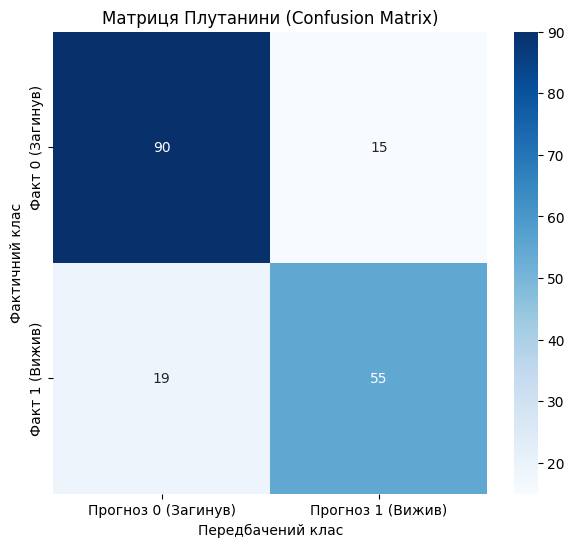


--- Фінальні результати моделі ---
Accuracy: 0.8101
F1-score: 0.7639


In [4]:
# =========================================================
# ЕТАП 4: ВІЗУАЛІЗАЦІЯ (Матриця Плутанини)
# =========================================================

# Матриця Плутанини вже була розрахована в Етапі 3:
# cm = confusion_matrix(y_test, y_pred_clf)

plt.figure(figsize=(7, 6))

# Побудова теплової карти (heatmap)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Прогноз 0 (Загинув)', 'Прогноз 1 (Вижив)'],
            yticklabels=['Факт 0 (Загинув)', 'Факт 1 (Вижив)'])
            
plt.title('Матриця Плутанини (Confusion Matrix)')
plt.ylabel('Фактичний клас')
plt.xlabel('Передбачений клас')
plt.show()

# =========================================================
# ПІДСУМОК (Для зручності)
# =========================================================
print("\n--- Фінальні результати моделі ---")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1-score: {f1:.4f}")